In [1]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
SOURCE_DIR = r'C:\Users\user\Documents\Deep Learning\2-3'
ANNOTATIONS_DIR = os.path.join(SOURCE_DIR, 'Original Dataset')

CLASS_0_DIR = os.path.join(SOURCE_DIR, 'класс0')
CLASS_1_DIR = os.path.join(SOURCE_DIR, 'класс1')
os.makedirs(CLASS_0_DIR, exist_ok=True)
os.makedirs(CLASS_1_DIR, exist_ok=True)

In [3]:
print(f"Пути сохранения:")
print(f"Класс 0: {CLASS_0_DIR}")
print(f"Класс 1: {CLASS_1_DIR}")

Пути сохранения:
Класс 0: C:\Users\user\Documents\Deep Learning\2-3\класс0
Класс 1: C:\Users\user\Documents\Deep Learning\2-3\класс1


In [4]:
p0 = [2, 4]
p1 = [5]

In [5]:
file_list = os.listdir(ANNOTATIONS_DIR)
image_files = [f for f in file_list if f.lower().endswith('.jpg')]
print(f"Обнаружено {len(image_files)} изображений в директории")
print(f"Соответствие классов: {p0} - класс0")
print(f"Соответствие классов: {p1} - класс1")

Обнаружено 231 изображений в директории
Соответствие классов: [2, 4] - класс0
Соответствие классов: [5] - класс1


In [6]:
total_class0 = 0
total_class1 = 0
img_num = 0

sample_class0 = None
sample_class1 = None

In [7]:
sample_class0 = None
sample_class1 = None

for img_file in image_files:
    name_only = os.path.splitext(img_file)[0]
    annotation_file = name_only + '.txt'
    annotation_path = os.path.join(ANNOTATIONS_DIR, annotation_file)
    img_path = os.path.join(ANNOTATIONS_DIR, img_file)

    if os.path.exists(annotation_path):
        original_img = Image.open(img_path)
        img_w, img_h = original_img.size
        img_cv = cv2.imread(img_path)

        with open(annotation_path, 'r') as file:
            annotations = file.readlines()

        count_0 = 0
        count_1 = 0

        for idx, annotation in enumerate(annotations):
            values = annotation.strip().split()
            if len(values) != 5:
                continue

            category = int(values[0])
            center_x = float(values[1])
            center_y = float(values[2])
            bbox_w = float(values[3])
            bbox_h = float(values[4])

            center_x_px = int(center_x * img_w)
            y_center_px = int(center_y * img_h)
            width_px = int(bbox_w * img_w)
            height_px = int(bbox_h * img_h)

            left = max(0, center_x_px - width_px // 2)
            top = max(0, y_center_px - height_px // 2)
            right = min(img_w, center_x_px + width_px // 2)
            bottom = min(img_h, y_center_px + height_px // 2)

            cropped_img = img_cv[top:bottom, left:right]

            if cropped_img.size > 0:
                if category in p0:
                    filename = f"tooth_{img_num:04d}_{idx:02d}.jpg"
                    output_path = os.path.join(CLASS_0_DIR, filename)
                    
                    pil_image = Image.fromarray(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB))
                    pil_image.save(output_path)
                    count_0 += 1
                    
                    if sample_class0 is None:
                        sample_class0 = pil_image
                        print(f"Сохранили образец класс0: {filename}")
                    
                elif category in p1:
                    filename = f"tooth_{img_num:04d}_{idx:02d}.jpg"
                    output_path = os.path.join(CLASS_1_DIR, filename)
                    
                    pil_image = Image.fromarray(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB))
                    pil_image.save(output_path)
                    count_1 += 1
                    
                    if sample_class1 is None:
                        sample_class1 = pil_image
                        print(f"Сохранили образец класс1: {filename}")

        total_class0 += count_0
        total_class1 += count_1
        img_num += 1

Сохранили образец класс1: tooth_0000_00.jpg
Сохранили образец класс0: tooth_0001_02.jpg


In [8]:
saved_class0 = len([f for f in os.listdir(CLASS_0_DIR) if f.endswith('.jpg')])
saved_class1 = len([f for f in os.listdir(CLASS_1_DIR) if f.endswith('.jpg')])

print(f"Сохранено изображений в класс0: {saved_class0}")
print(f"Сохранено изображений в класс1: {saved_class1}")
print(f"Всего сохранено: {saved_class0 + saved_class1}")

Сохранено изображений в класс0: 293
Сохранено изображений в класс1: 651
Всего сохранено: 944


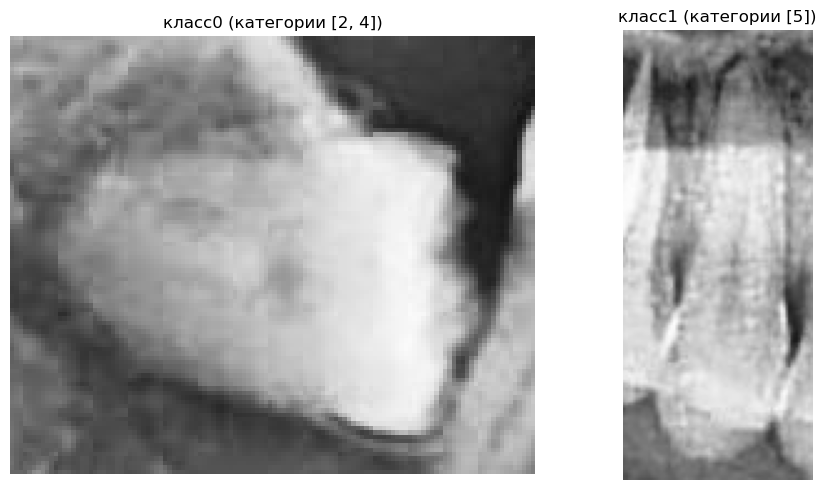

In [9]:
if sample_class0 is not None:
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    sample_class0_np = np.array(sample_class0)
    plt.imshow(sample_class0_np)
    plt.title(f'класс0 (категории {p0})')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    sample_class1_np = np.array(sample_class1)
    plt.imshow(sample_class1_np)
    plt.title(f'класс1 (категории {p1})')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Не удалось найти примеры изображений для отображения")